# Vector Applications

Notebook ini merangkum Chapter 4 dari *Practical Linear Algebra for Data Science*. Chapter ini menunjukkan bagaimana konsep vector dari chapter sebelumnya digunakan dalam aplikasi data science, terutama pada **correlation**, **cosine similarity**, **time series filtering**, dan **k-means clustering**.

Isi dibuat ringkas, tetapi tetap mencakup konsep utama, rumus yang memang dibahas pada chapter, contoh kode, dan kesimpulan.

## Tujuan Pembelajaran

- Memahami hubungan dot product dengan Pearson correlation.
- Membedakan Pearson correlation dan cosine similarity.
- Memahami penggunaan dot product pada time series filtering.
- Memahami konsep kernel pada filtering.
- Memahami langkah dasar algoritma k-means clustering.
- Melihat bagaimana vector norms dan broadcasting digunakan dalam k-means.

## Ringkasan Chapter

Chapter ini menghubungkan konsep vector dengan aplikasi nyata dalam data science dan machine learning. Bagian pertama membahas correlation dan cosine similarity. Keduanya sama-sama menggunakan dot product, tetapi berbeda pada proses normalisasi. Pearson correlation melakukan mean-centering terlebih dahulu, sedangkan cosine similarity tidak.

Bagian kedua membahas time series filtering. Filtering dipahami sebagai proses mencocokkan sebuah kernel pendek dengan potongan sinyal menggunakan dot product. Hasil dot product tersebut menunjukkan seberapa mirip bagian sinyal dengan pola yang dicari oleh kernel.

Bagian terakhir membahas k-means clustering. Chapter ini tidak memakai library clustering siap pakai, tetapi menjelaskan algoritmanya secara manual agar terlihat bagaimana vector, Euclidean distance, vector norms, dan broadcasting digunakan dalam proses clustering.

## Struktur Pembahasan Chapter

| Bagian | Inti Pembahasan |
|---|---|
| Correlation and Cosine Similarity | Dot product digunakan untuk mengukur hubungan atau similarity antara dua vector. |
| Correlation Versus Cosine Similarity | Pearson correlation melakukan mean-centering, sedangkan cosine similarity tidak. |
| Time Series Filtering | Kernel dicocokkan dengan potongan sinyal menggunakan dot product. |
| k-Means Clustering | Data dikelompokkan berdasarkan jarak terdekat ke centroid. |
| Code Exercises | Latihan untuk correlation, filtering, dan k-means. |

## Persiapan Library

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(2024)

## Correlation and Cosine Similarity

Correlation coefficient adalah angka tunggal yang mengukur hubungan linear antara dua variable. Nilainya berada dari $-1$ sampai $+1$:

- $+1$ berarti hubungan linear positif sempurna.
- $-1$ berarti hubungan linear negatif sempurna.
- $0$ berarti tidak ada hubungan linear.

Chapter ini juga menekankan bahwa correlation adalah ukuran linear. Artinya, dua variable dapat memiliki pola nonlinear yang jelas, tetapi correlation-nya tetap mendekati nol.

## Rumus Pearson Correlation

Pearson correlation coefficient ditulis sebagai:

$$
\rho =
\frac{
\sum_{i=1}^{n}(x_i-\bar{x})(y_i-\bar{y})
}{
\sqrt{\sum_{i=1}^{n}(x_i-\bar{x})^2}
\sqrt{\sum_{i=1}^{n}(y_i-\bar{y})^2}
}
$$

Keterangan:

- $\rho$ = Pearson correlation coefficient
- $x_i$ = nilai ke-$i$ pada variable $x$
- $y_i$ = nilai ke-$i$ pada variable $y$
- $\bar{x}$ = rata-rata variable $x$
- $\bar{y}$ = rata-rata variable $y$
- $n$ = jumlah data

Rumus ini menunjukkan dua proses penting: mean-centering dan normalisasi dengan vector norm.

## Pearson Correlation dalam Notasi Linear Algebra

Jika $x$ dan $y$ sudah di-mean-center, correlation dapat ditulis sebagai dot product yang dinormalisasi:

$$
\rho =
\frac{x^Ty}{\|x\|\|y\|}
$$

Keterangan:

- $x^Ty$ = dot product antara vector $x$ dan $y$
- $\|x\|$ = norm vector $x$
- $\|y\|$ = norm vector $y$

Jadi, Pearson correlation dapat dipahami sebagai dot product antara dua variable yang sudah di-mean-center, lalu dinormalisasi oleh panjang kedua vector.

## Cosine Similarity

Cosine similarity berasal dari bentuk geometris dot product.

$$
\cos(\theta_{x,y}) =
\frac{\alpha}{\|x\|\|y\|}
$$

Karena $\alpha$ adalah dot product antara $x$ dan $y$, maka:

$$
\cos(\theta_{x,y}) =
\frac{x^Ty}{\|x\|\|y\|}
$$

Perbedaannya dengan Pearson correlation adalah cosine similarity tidak melakukan mean-centering terlebih dahulu.

In [2]:
def pearson_and_cosine(x, y):
    x = np.asarray(x)
    y = np.asarray(y)

    x_centered = x - np.mean(x)
    y_centered = y - np.mean(y)

    pearson = np.dot(x_centered, y_centered) / (
        np.linalg.norm(x_centered) * np.linalg.norm(y_centered)
    )

    cosine = np.dot(x, y) / (
        np.linalg.norm(x) * np.linalg.norm(y)
    )

    return pearson, cosine

x = np.array([0, 1, 2, 3])
y = np.array([100, 101, 102, 103])

pearson, cosine = pearson_and_cosine(x, y)

print("Pearson correlation:", pearson)
print("Cosine similarity:", cosine)

Pearson correlation: 0.9999999999999998
Cosine similarity: 0.8083174787557303


## Analisis Correlation vs Cosine Similarity

Contoh di atas menunjukkan bahwa Pearson correlation dan cosine similarity dapat menghasilkan nilai berbeda. Variable `[0, 1, 2, 3]` dan `[100, 101, 102, 103]` memiliki pola perubahan yang sama, sehingga correlation-nya sempurna. Namun, cosine similarity tidak bernilai 1 karena kedua vector memiliki skala numerik yang berbeda.

Tidak ada ukuran yang selalu lebih benar. Keduanya memakai asumsi berbeda, sehingga interpretasinya juga berbeda.

## Simulasi Offset Mean

Chapter memberi latihan untuk melihat bagaimana offset memengaruhi cosine similarity, tetapi tidak memengaruhi Pearson correlation. Simulasi berikut mengikuti ide tersebut.

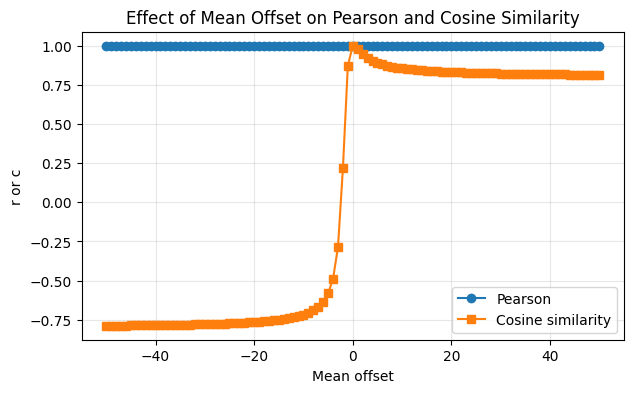

In [3]:
offsets = np.arange(-50, 51)
base = np.arange(4)

pearsons = []
cosines = []

for offset in offsets:
    y = base + offset
    r, c = pearson_and_cosine(base, y)
    pearsons.append(r)
    cosines.append(c)

plt.figure(figsize=(7, 4))
plt.plot(offsets, pearsons, "o-", label="Pearson")
plt.plot(offsets, cosines, "s-", label="Cosine similarity")
plt.xlabel("Mean offset")
plt.ylabel("r or c")
plt.title("Effect of Mean Offset on Pearson and Cosine Similarity")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Time Series Filtering and Feature Detection

Filtering adalah metode untuk mendeteksi fitur tertentu dalam time series. Dalam filtering, sebuah template pendek disebut **kernel**. Kernel dicocokkan dengan potongan sinyal menggunakan dot product.

Proses dasarnya:

1. Ambil potongan sinyal dengan panjang yang sama seperti kernel.
2. Hitung dot product antara kernel dan potongan sinyal.
3. Geser kernel satu langkah ke kanan.
4. Ulangi proses sampai seluruh sinyal diproses.

Chapter menyebut prosedur ini sebagai dasar dari convolution, meskipun detail convolution lengkap tidak dibahas.

## Dot Product dalam Filtering

Jika kernel $k$ dan potongan sinyal $s$ memiliki panjang yang sama, hasil filtering lokal dapat dihitung sebagai:

$$
f = k^Ts
$$

Keterangan:

- $f$ = nilai hasil filtering pada satu posisi waktu
- $k$ = kernel
- $s$ = potongan sinyal
- $k^Ts$ = dot product antara kernel dan potongan sinyal

Nilai $f$ besar jika potongan sinyal memiliki pola yang mirip dengan kernel.

## Contoh Edge Detector

Chapter memberi contoh kernel sederhana untuk edge detection:

$$
k =
\begin{bmatrix}
-1 & 1
\end{bmatrix}
$$

Kernel ini menghasilkan nilai besar ketika terdapat perubahan tajam pada sinyal. Jika sinyal datar, dot product-nya mendekati nol.

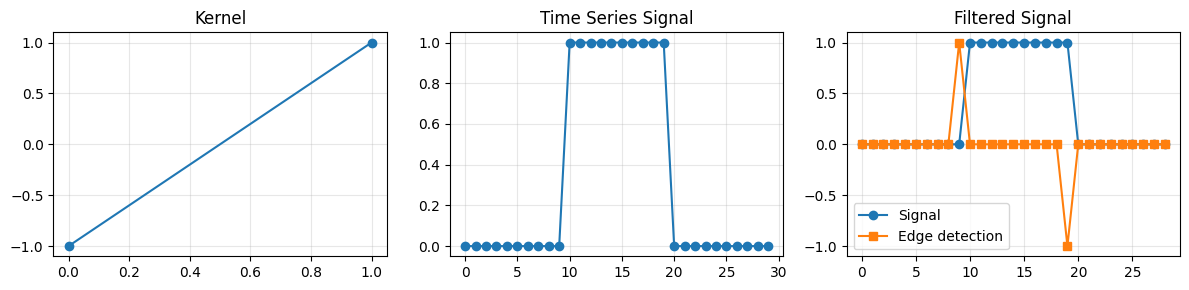

In [4]:
kernel = np.array([-1, 1])

signal = np.zeros(30)
signal[10:20] = 1

filtered = np.zeros(len(signal)-1)

for i in range(len(filtered)):
    filtered[i] = np.dot(kernel, signal[i:i+2])

fig, axes = plt.subplots(1, 3, figsize=(12, 3))

axes[0].plot(kernel, "o-")
axes[0].set_title("Kernel")

axes[1].plot(signal, "o-")
axes[1].set_title("Time Series Signal")

axes[2].plot(signal[:-1], "o-", label="Signal")
axes[2].plot(filtered, "s-", label="Edge detection")
axes[2].set_title("Filtered Signal")
axes[2].legend()

for ax in axes:
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Smoothing dengan Gaussian-like Kernel

Chapter juga memberi latihan smoothing menggunakan kernel berbentuk bell-shaped:

$$
k =
\begin{bmatrix}
0 & .1 & .3 & .8 & 1 & .8 & .3 & .1 & 0
\end{bmatrix}
$$

Kernel kemudian diskalakan agar jumlah seluruh elemennya sama dengan 1. Filtering dengan kernel ini menghasilkan sinyal yang lebih halus, atau disebut low-pass filtering.

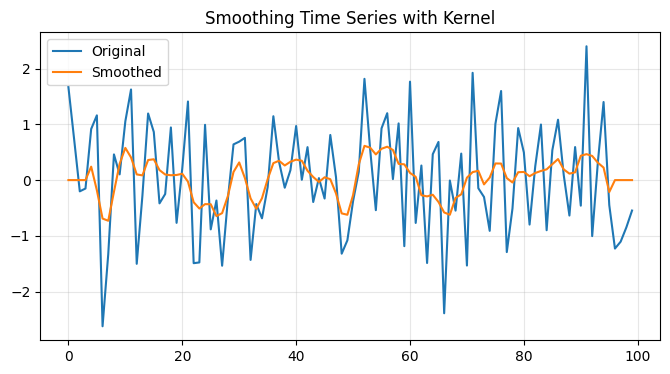

In [5]:
signal = np.random.randn(100)

kernel = np.array([0, .1, .3, .8, 1, .8, .3, .1, 0])
kernel = kernel / np.sum(kernel)

half_k = len(kernel) // 2
smoothed = np.zeros(len(signal))

for i in range(half_k, len(signal)-half_k):
    segment = signal[i-half_k:i+half_k+1]
    smoothed[i] = np.dot(kernel, segment)

plt.figure(figsize=(8, 4))
plt.plot(signal, label="Original")
plt.plot(smoothed, label="Smoothed")
plt.title("Smoothing Time Series with Kernel")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## k-Means Clustering

k-means clustering adalah metode unsupervised learning untuk mengelompokkan data multivariate ke dalam sejumlah kecil kelompok. Ide dasarnya adalah mengelompokkan data berdasarkan jarak ke centroid terdekat.

Chapter ini membahas k-means untuk menunjukkan bagaimana vector, vector norms, Euclidean distance, dan broadcasting digunakan dalam algoritma machine learning.

## Langkah Algoritma k-Means

1. Tentukan jumlah cluster $k$.
2. Pilih $k$ centroid awal secara acak dari data.
3. Hitung jarak setiap data point ke setiap centroid.
4. Assign setiap data point ke centroid terdekat.
5. Update centroid sebagai rata-rata data dalam cluster.
6. Ulangi sampai jumlah iterasi tertentu atau sampai centroid tidak banyak berubah.

## Rumus Euclidean Distance

Untuk satu data observation dan satu centroid dalam 2D:

$$
\delta_{i,j}
=
\sqrt{
(d_i^x-c_j^x)^2
+
(d_i^y-c_j^y)^2
}
$$

Keterangan:

- $\delta_{i,j}$ = jarak data observation ke-$i$ ke centroid ke-$j$
- $d_i^x$ = nilai fitur $x$ pada data ke-$i$
- $d_i^y$ = nilai fitur $y$ pada data ke-$i$
- $c_j^x$ = koordinat $x$ centroid ke-$j$
- $c_j^y$ = koordinat $y$ centroid ke-$j$

Dalam implementasi k-means, square root dapat dihilangkan karena distance dan squared distance memiliki urutan yang sama.

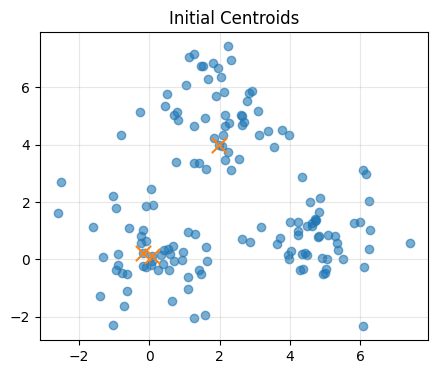

In [6]:
# Membuat data 2D sederhana dengan 3 kelompok
n = 50

data = np.vstack([
    np.random.randn(n, 2) + np.array([0, 0]),
    np.random.randn(n, 2) + np.array([5, 1]),
    np.random.randn(n, 2) + np.array([2, 5])
])

k = 3

# Initialize k centroids as random data points
ridx = np.random.choice(range(len(data)), k, replace=False)
centroids = data[ridx, :]

plt.figure(figsize=(5, 4))
plt.scatter(data[:, 0], data[:, 1], alpha=0.6)
plt.scatter(centroids[:, 0], centroids[:, 1], marker="x", s=120)
plt.title("Initial Centroids")
plt.grid(alpha=0.3)
plt.show()

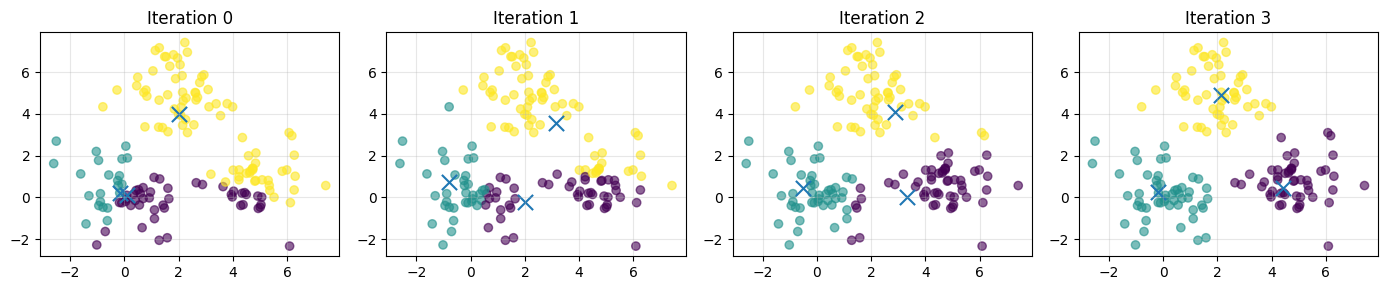

In [7]:
fig, axes = plt.subplots(1, 4, figsize=(14, 3))

for iteration in range(4):

    # Compute squared distances using broadcasting
    dists = np.zeros((data.shape[0], k))
    for ci in range(k):
        dists[:, ci] = np.sum((data - centroids[ci, :])**2, axis=1)

    # Assign each point to closest centroid
    groupidx = np.argmin(dists, axis=1)

    axes[iteration].scatter(data[:, 0], data[:, 1], c=groupidx, alpha=0.6)
    axes[iteration].scatter(centroids[:, 0], centroids[:, 1], marker="x", s=120)
    axes[iteration].set_title(f"Iteration {iteration}")
    axes[iteration].grid(alpha=0.3)

    # Update centroids
    for ki in range(k):
        centroids[ki, :] = [
            np.mean(data[groupidx == ki, 0]),
            np.mean(data[groupidx == ki, 1])
        ]

plt.tight_layout()
plt.show()

## Analisis k-Means

Kode k-means di atas mengikuti langkah yang dijelaskan dalam chapter. Jarak dihitung menggunakan squared distance karena square root tidak mengubah centroid mana yang paling dekat. Broadcasting digunakan ketika data matrix dikurangi dengan centroid, sehingga perhitungan jarak dapat dilakukan lebih ringkas.

Chapter juga menekankan bahwa implementasi produksi biasanya lebih canggih, misalnya dalam pemilihan centroid awal, stopping criteria, dan pemilihan nilai $k$. Namun, inti algoritma k-means tetap bergantung pada operasi vector dan linear algebra.

## Ringkasan Konsep Penting

| Konsep | Ringkasan |
|---|---|
| Pearson correlation | Dot product dari variable yang sudah di-mean-center dan dinormalisasi. |
| Cosine similarity | Dot product yang dinormalisasi tanpa mean-centering. |
| Mean-centering | Mengurangi setiap nilai dengan rata-rata variable. |
| Kernel | Template pendek untuk mendeteksi pola dalam sinyal. |
| Filtering | Menggeser kernel pada sinyal dan menghitung dot product lokal. |
| Low-pass filtering | Filtering yang menghaluskan sinyal. |
| k-means | Clustering berdasarkan jarak data ke centroid. |
| Centroid | Titik pusat cluster. |
| Broadcasting | Mekanisme NumPy untuk menghitung operasi array secara efisien. |

## Kesimpulan Chapter

Chapter ini menunjukkan bahwa operasi vector tidak hanya bersifat abstrak, tetapi langsung muncul dalam aplikasi data science. Pearson correlation dan cosine similarity menggunakan dot product sebagai inti perhitungannya, tetapi berbeda pada perlakuan mean-centering.

Dot product juga digunakan dalam time series filtering. Kernel pendek digeser sepanjang sinyal, lalu dot product dihitung pada setiap posisi untuk mendeteksi fitur tertentu atau menghaluskan sinyal.

Pada k-means clustering, konsep vector muncul melalui data points, centroids, Euclidean distance, dan broadcasting. Dengan memahami vector operations, algoritma k-means menjadi lebih mudah dipahami sebagai proses menghitung jarak, memilih centroid terdekat, dan memperbarui posisi centroid.

Secara keseluruhan, chapter ini memperlihatkan bagaimana konsep vector dari chapter sebelumnya digunakan sebagai dasar dalam statistics, signal processing, dan machine learning.